## Importing libraries

In [15]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm.notebook import tqdm
from collections import Counter

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\senas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# EDA

## Loading dataset
First load the dataset downloaded from Kaggle.

https://www.kaggle.com/datasets/filipefilardi/20-newsgroup-preprocessed

This is a preprocessed dataset. This means that the documents from the original dataset have been already order in a csv format with their respective targets. It also includes a preprocessed column which will server as a baseline for our own preprocessing on the dataset. 

In [3]:
df = pd.read_csv('./../data/processed/20newsgroup_preprocessed.csv', on_bad_lines='skip', delimiter=";")
print(df.shape)
df.head()

(18828, 3)


,target,text,text_cleaned
0,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,atheist resources addresses atheist organizati...
1,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,begin pgp signed message introduction atheism ...
2,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,article charley wingate writes well john quite...
3,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: R...,kings become philosophers philosophers become ...
4,alt.atheism,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,article bob mcgwier writes however hate econom...


## Checking for empty values
Start by checking for empty values in the dataset to see if there are any.

In [4]:
df.isnull().sum()

target           0
text             0
text_cleaned    36
dtype: int64

We can see that the dataset only has missing values in the preprocessed field. Next lets check one of these missing fields to see what does the original document contain.

In [5]:
first_null_row = df[df['text_cleaned'].isnull()].iloc[0]
print(first_null_row['text'])

From: Edwin Gans
Subject: Atheism

 



As we can see from the output the dataset contains some junk values where there is no actual content just the headers, which get filtered out during preprocessing.

## Check distribution of targets

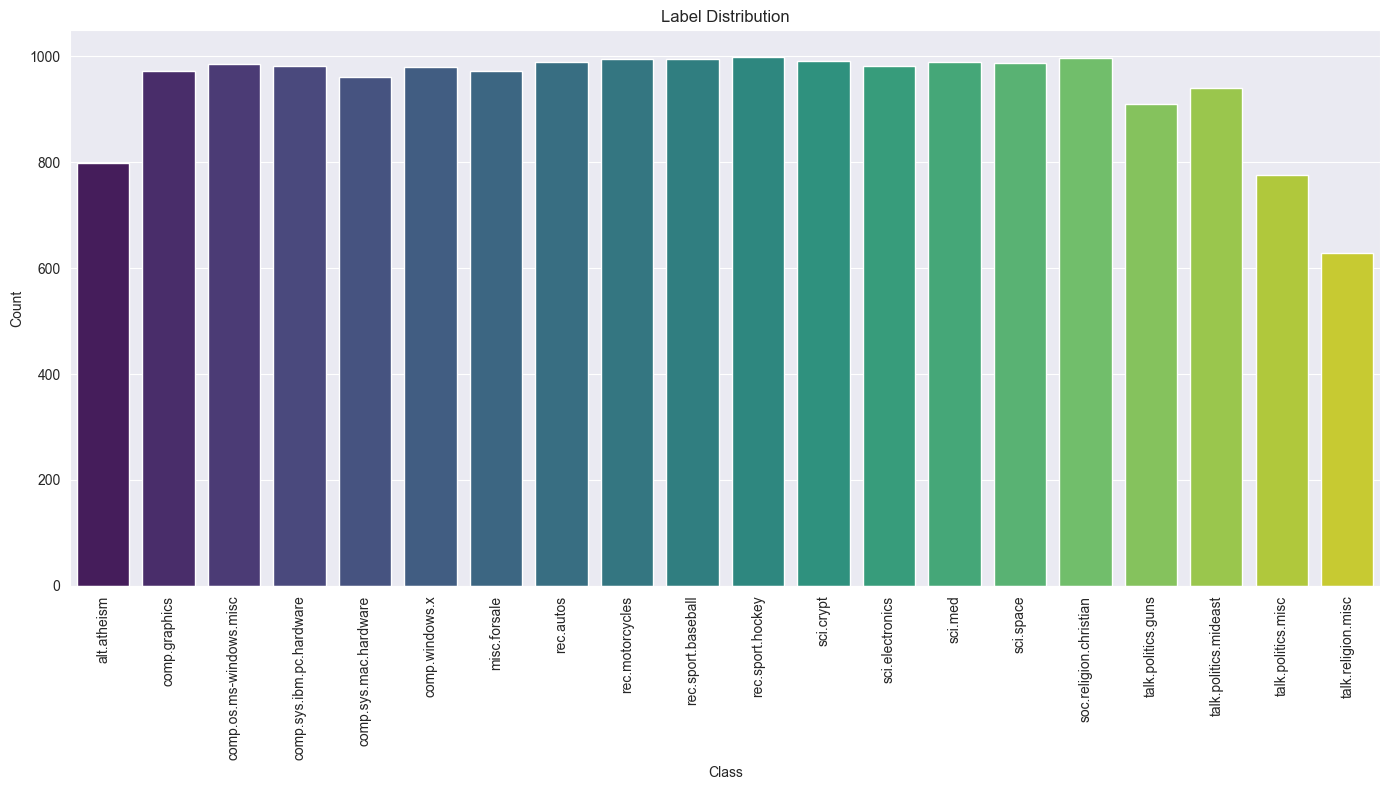

In [9]:
def plot_label_distribution(df, label_column='target'):
    counts = df[label_column].value_counts().sort_index()
    data = pd.DataFrame({label_column: counts.index, 'Count': counts.values})

    plt.figure(figsize=(14, 8))
    sns.barplot(
        data=data,
        x=label_column,
        y='Count',
        hue=label_column,
        palette="viridis",
        legend=False
    )

    plt.title('Label Distribution')
    plt.ylabel('Count')
    plt.xlabel('Class')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


plot_label_distribution(df)

As we can see from the plot the targets are mostly balanced, but they are not perfect. So during training if we use a neural network BalancedCrossEntropy should be used instead of regular CrossEntropy.

## Check common words

Next we should check the most common words in each target class. For this we will use the cleaned column as it does not include stopwords and common headers so the remaining words represent the target class much better. We will present this in a word cloud form.

Generating Word Clouds:   0%|          | 0/20 [00:00<?, ?it/s]

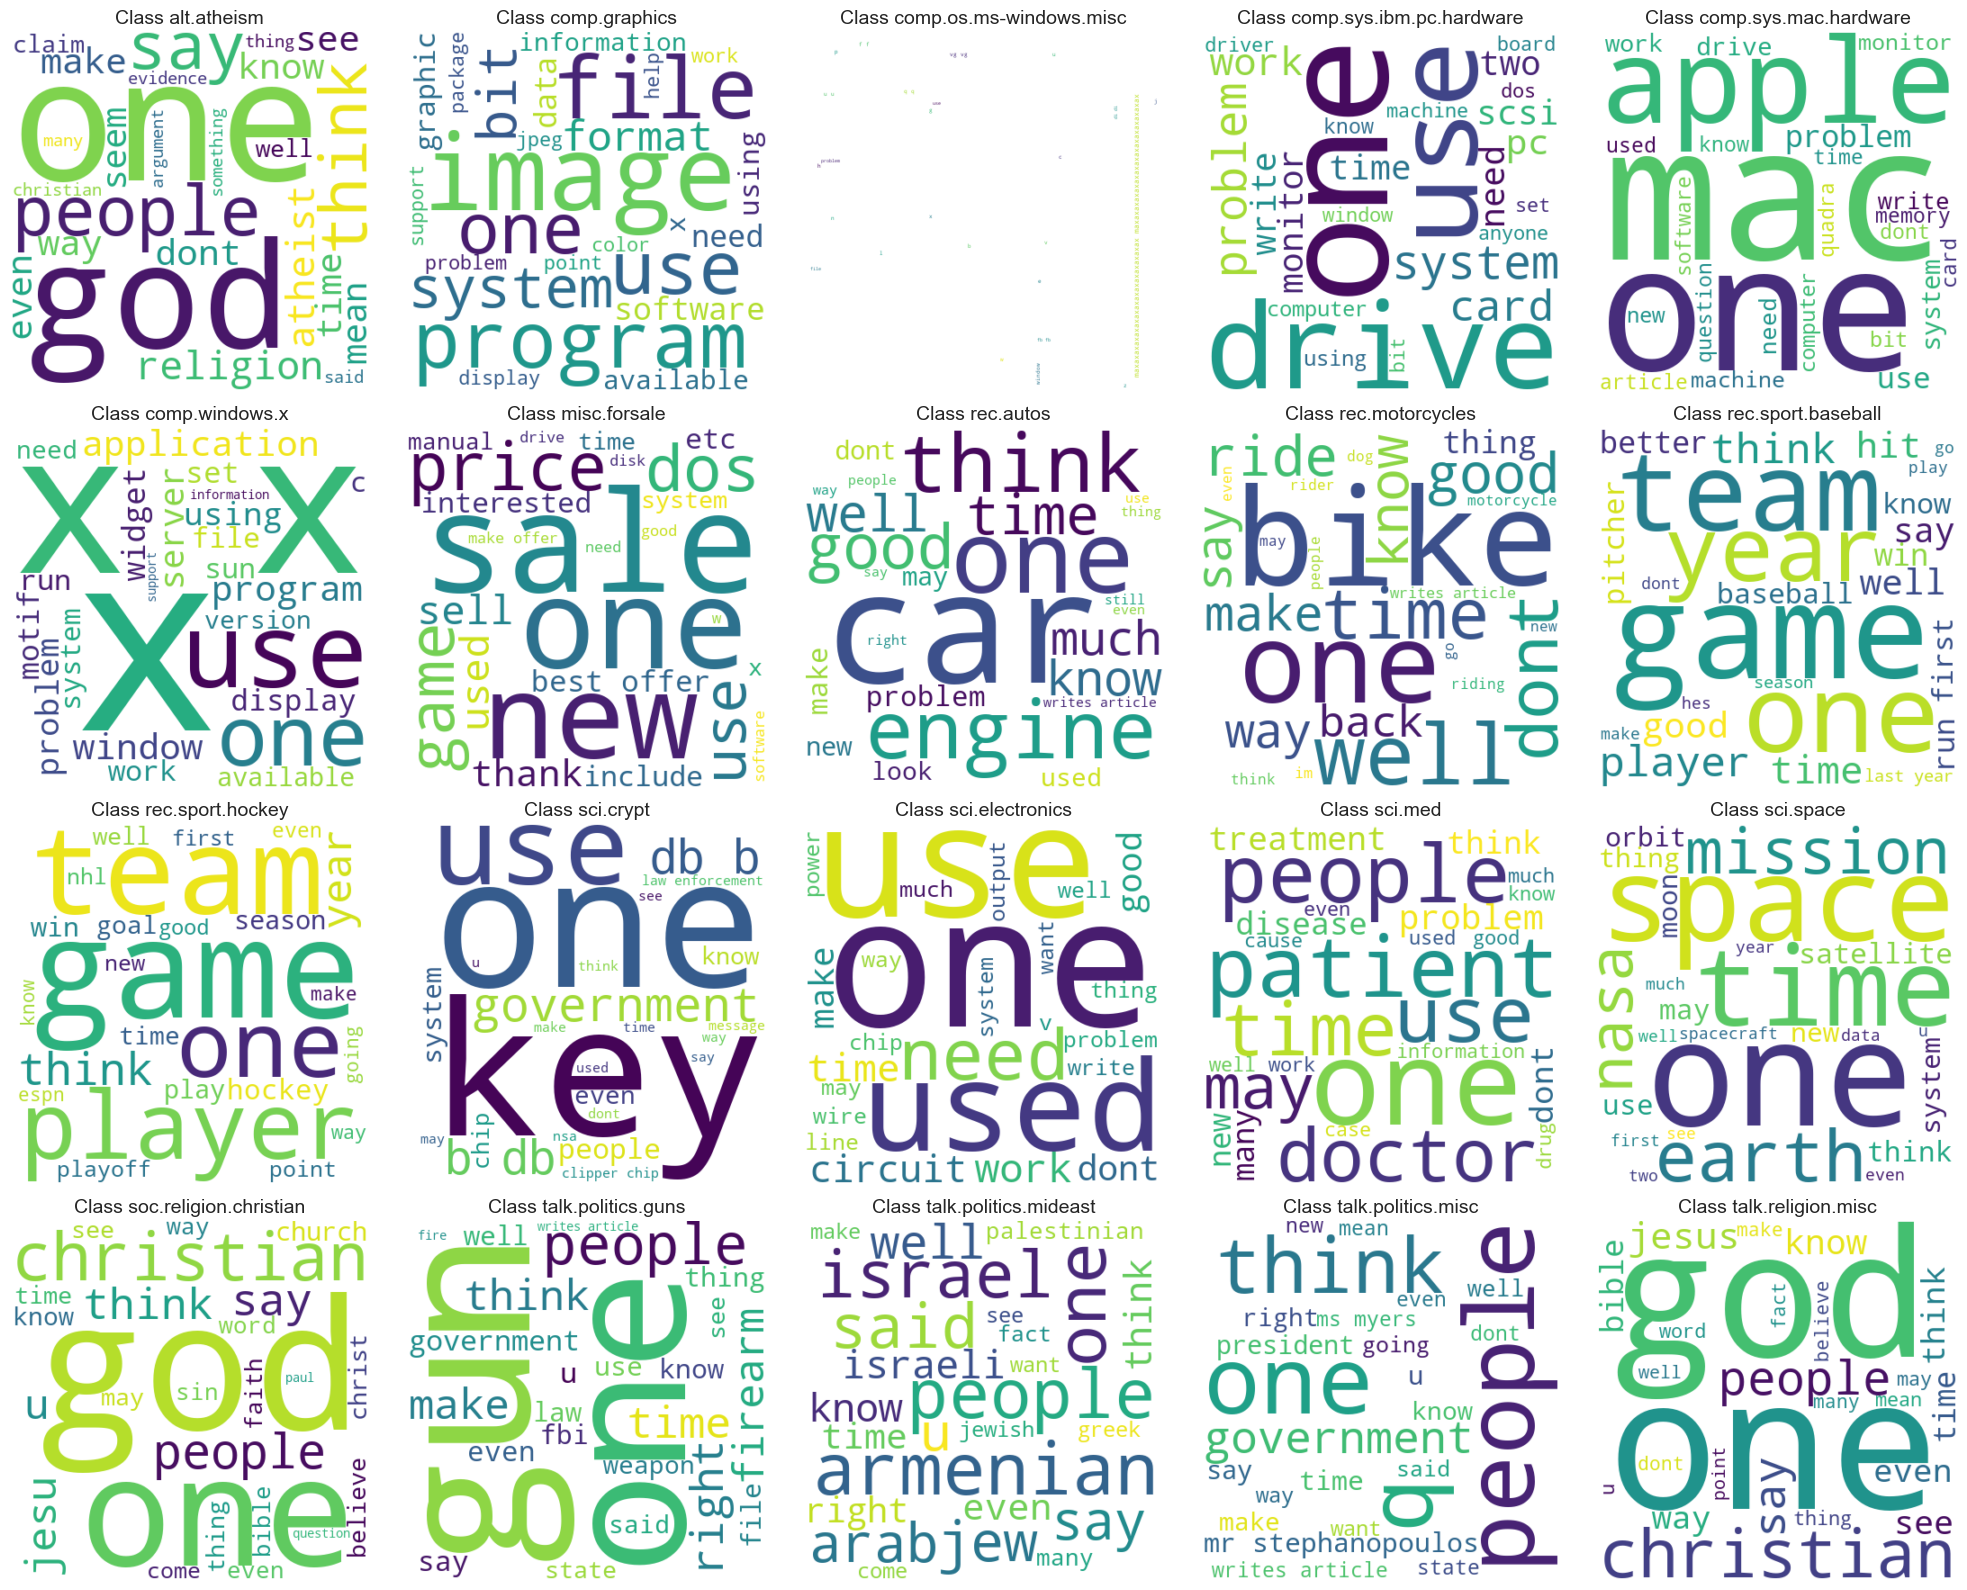

In [13]:
def plot_wordclouds_per_class(df, text_column='text_cleaned', label_column='target', max_words=25):
    classes = df[label_column].unique()
    classes = sorted(classes)  # Sort to have consistent layout
    n_classes = len(classes)

    fig, axs = plt.subplots(4, 5, figsize=(20, 16))
    axs = axs.flatten()

    for i, target_class in enumerate(tqdm(classes, desc="Generating Word Clouds")):
        class_text = df[df[label_column] == target_class][text_column].dropna().str.cat(sep=' ')

        wordcloud = WordCloud(
            width=400, height=400,
            max_words=max_words,
            background_color='white',
            colormap='viridis'
        ).generate(class_text)

        axs[i].imshow(wordcloud, interpolation='bilinear')
        axs[i].set_title(f"Class {target_class}", fontsize=14)
        axs[i].axis('off')

    # Hide any unused subplots
    for j in range(i+1, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

plot_wordclouds_per_class(df)

From these word clouds we can have a picture of which words are most common among each class. We can see that religion, christianity, and atheism use similar vocabulary this could be a problem if we only use few features during training.

Another find is that one is not included in the stopwords, yet it acts like one. Little semantic meaning on its own and is very common in most classes. 

We can also see that the word cloud for windows misc is messed up as it contains a very long word. We will look into this next.

In [16]:
def print_top_words_for_class(df, target_class, text_column='text_cleaned', label_column='target', top_n=25):
    # Select rows for the given class
    class_texts = df[df[label_column] == target_class][text_column].dropna()

    # Concatenate all texts into one big string
    all_text = ' '.join(class_texts)

    # Tokenize by simple space
    words = all_text.split()

    # Count word frequencies
    word_counts = Counter(words)

    # Print the top N most common words
    top_words = word_counts.most_common(top_n)

    print(f"Top {top_n} words for class '{target_class}':")
    for word, count in top_words:
        print(f"{word}: {count}")

print_top_words_for_class(df, target_class='comp.os.ms-windows.misc')

Top 25 words for class 'comp.os.ms-windows.misc':
q: 3875
maxaxaxaxaxaxaxaxaxaxaxaxaxaxax: 3317
f: 3230
u: 2968
w: 2108
p: 1862
e: 1701
windows: 1506
l: 1327
v: 1259
vg: 1224
g: 1183
c: 1164
x: 1130
fb: 1032
z: 988
k: 985
r: 963
j: 920
h: 880
b: 827
n: 758
file: 640
di: 623
dos: 542


We can see that the top most used words for this class are only single or double letters with no meaning. There is also 'maxaxaxaxaxaxaxaxaxaxaxaxaxaxax'. These along with the stopwords and one should be removed.

Next lets move on to doing our own preprocessing.

# Data Preprocessing

Lets start with a clean canvas by replacing the cleaned thext with the original documents which we will refine step by step.

In [23]:
df['text_cleaned'] = df['text']
df.head()

,target,text,text_cleaned
0,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,From: mathew <mathew@mantis.co.uk>\nSubject: A...
1,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,From: mathew <mathew@mantis.co.uk>\nSubject: A...
2,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...
3,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: R...,From: mathew <mathew@mantis.co.uk>\nSubject: R...
4,alt.atheism,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...


## Preprocessing text

### Removing headers from text.

We do this by removing everything until the first completely empty line. Some of the headers continue beyond this but there are cases where the content starts right after so to not remove any valuable content we only remove up to the first empty line instead of the second.

In [24]:
# Remove text until the first empty line
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'^(?:.*\n)*?\s*?\n', '', x, count=1))
df.head()

,target,text,text_cleaned
0,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,Archive-name: atheism/resources\nAlt-atheism-a...
1,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,Archive-name: atheism/introduction\nAlt-atheis...
2,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,In article <65974@mimsy.umd.edu>\nmangoe@cs.um...
3,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: R...,dmn@kepler.unh.edu (...until kings become phil...
4,alt.atheism,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,In article <N4HY.93Apr5120934@harder.ccr-p.ida...


### Removing stopwords.

We use the english stopwords defined in the nltk library and add our custom words to it.

In [25]:
stop_words = set(stopwords.words('english'))
custom_stopwords = {"one", "maxaxaxaxaxaxaxaxaxaxaxaxaxaxax"}
stop_words = stop_words.union(custom_stopwords)

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])
    
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: remove_stopwords(x))
df.head()

,target,text,text_cleaned
0,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,Archive-name: atheism/resources Alt-atheism-ar...
1,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,Archive-name: atheism/introduction Alt-atheism...
2,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,In article <65974@mimsy.umd.edu> mangoe@cs.umd...
3,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: R...,dmn@kepler.unh.edu (...until kings become phil...
4,alt.atheism,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,In article <N4HY.93Apr5120934@harder.ccr-p.ida...


### Removing emails and phone numbers.

Next we go on to remove all phone numbers and emails using regex. 

In [26]:
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'\b[\w\-.]+?@[a-zA-Z0-9]+?(\.[a-zA-Z0-9-]+?){1,4}\b', '', x))
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'\b\d{10}\b', '', x))
df.head()

,target,text,text_cleaned
0,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,Archive-name: atheism/resources Alt-atheism-ar...
1,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,Archive-name: atheism/introduction Alt-atheism...
2,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,In article <> (Charley Wingate) writes: >>Wel...
3,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: R...,(...until kings become philosophers philosoph...
4,alt.atheism,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,"In article <-p.ida.org>, -p.ida.org (Bob McGwi..."


### Removing special characters, line breaks and extra whitespaces then convert to lowercase.

In [27]:
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', ' ', x))
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'\n', ' ', x))
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'\s+', ' ', x))
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: x.lower())
df.head()

,target,text,text_cleaned
0,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism resources alt atheism arc...
1,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism introduction alt atheism ...
2,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,in article charley wingate writes well john qu...
3,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: R...,until kings become philosophers philosophers ...
4,alt.atheism,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,in article p ida org p ida org bob mcgwier wri...


### Remove remaining numbers and stopwords.

If any numbers or stopwords remained that weren't found before cleaning remove them.

In [28]:
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'\b\w*\d\w*\b', '', x))
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: remove_stopwords(x))
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'(\w)\1{2,}', r'\1', x)) 
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'\b\w{2}\b', '', x).strip())
df.head()

,target,text,text_cleaned
0,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism resources alt atheism arc...
1,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism introduction alt atheism ...
2,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,article charley wingate writes well john quite...
3,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: R...,kings become philosophers philosophers become ...
4,alt.atheism,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,article p ida org p ida org bob mcgwier writes...


## Remove one or two-letter words

In [30]:
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'\b\w{1,2}\b', '', x))
df['text_cleaned'] = df['text_cleaned'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
df.head()

,target,text,text_cleaned
0,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism resources alt atheism arc...
1,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: A...,archive name atheism introduction alt atheism ...
2,alt.atheism,From: I3150101@dbstu1.rz.tu-bs.de (Benedikt Ro...,article charley wingate writes well john quite...
3,alt.atheism,From: mathew <mathew@mantis.co.uk>\nSubject: R...,kings become philosophers philosophers become ...
4,alt.atheism,From: strom@Watson.Ibm.Com (Rob Strom)\nSubjec...,article ida org ida org bob mcgwier writes how...


In [31]:
df.shape

(18828, 3)

## Check word clouds again

Generating Word Clouds:   0%|          | 0/20 [00:00<?, ?it/s]

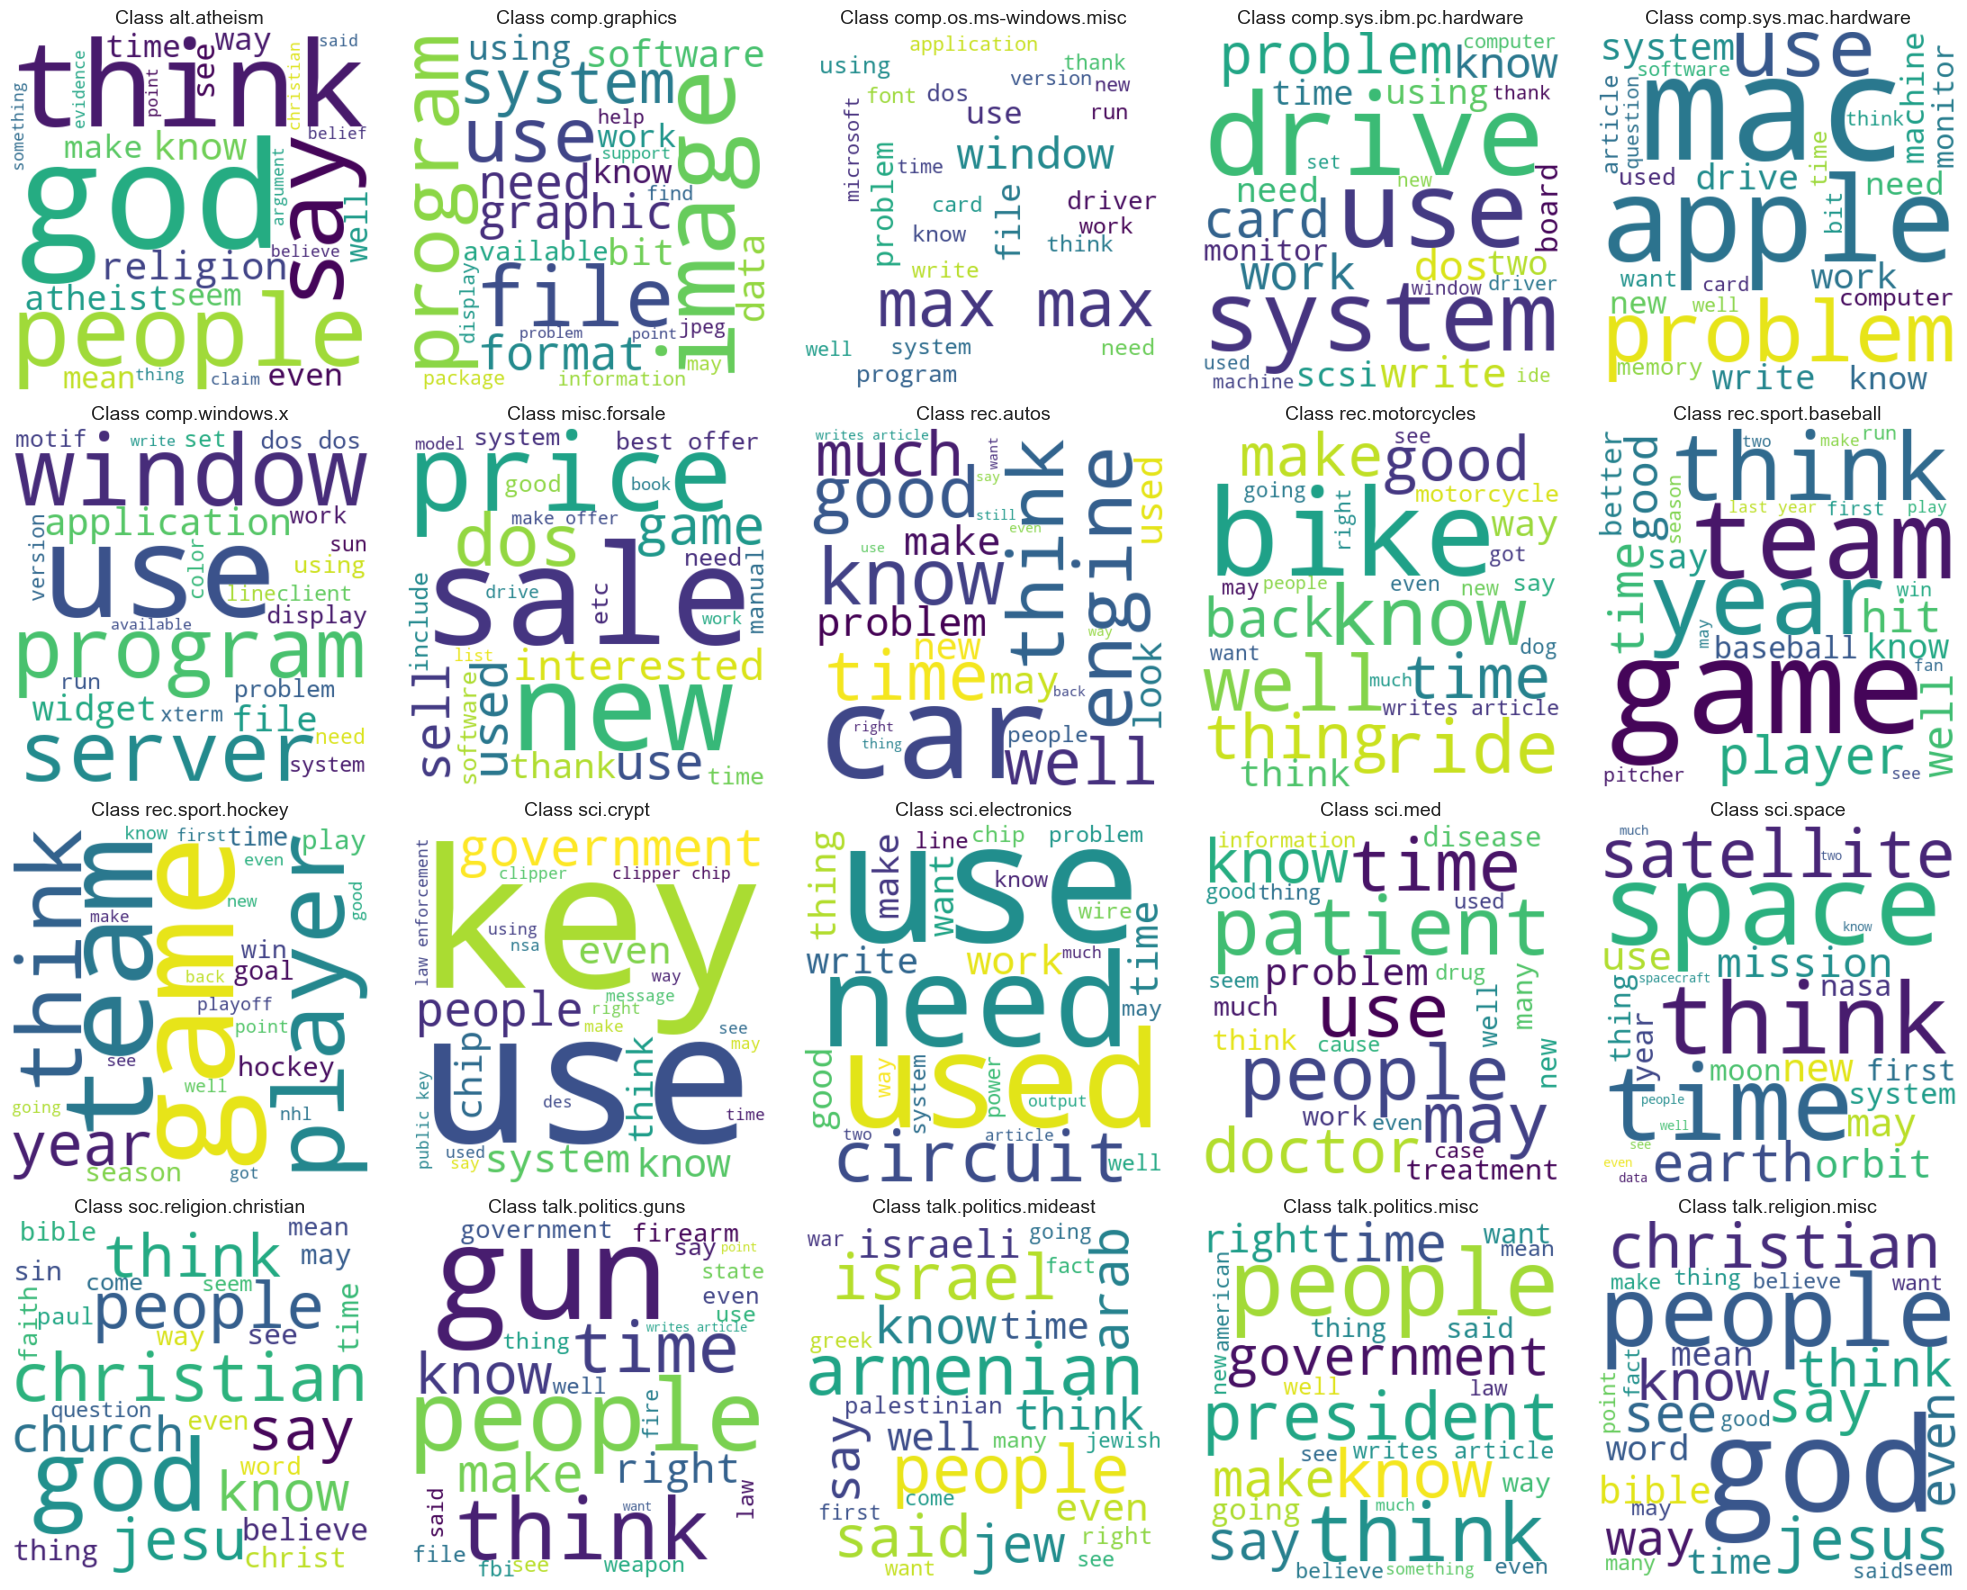

In [32]:
plot_wordclouds_per_class(df)

As we can see the resulting word clouds are looking much better than the previous ones.

## Saving preprocessed dataset

As a last step save the resulting dataset for use in training.

In [33]:
df.to_csv('./../data/processed/20newsgroup_preprocessed_own.csv', sep=';', index=False)